Epoch 1/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 167s 43ms/step - loss: 2.7012e-04 - mae: 0.0059 - val_loss: 3.3263e-06 - val_mae: 0.0014
Epoch 2/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 183s 38ms/step - loss: 1.0969e-04 - mae: 0.0041 - val_loss: 1.0084e-05 - val_mae: 0.0020
Epoch 3/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 142s 39ms/step - loss: 8.1387e-05 - mae: 0.0037 - val_loss: 2.5505e-05 - val_mae: 0.0044
Epoch 4/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 218s 43ms/step - loss: 7.2635e-05 - mae: 0.0035 - val_loss: 1.0951e-04 - val_mae: 0.0104
Epoch 5/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 194s 41ms/step - loss: 6.9760e-05 - mae: 0.0034 - val_loss: 1.1115e-04 - val_mae: 0.0049
Epoch 6/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 195s 39ms/step - loss: 5.1492e-05 - mae: 0.0031 - val_loss: 1.6010e-04 - val_mae: 0.0061
Epoch 7/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 203s 39ms/step - loss: 4.8674e-05 - mae: 0.0030 - val_loss: 2.3124e-04 - val_mae: 0.0067
Epoch 8/100
3683/3683 ━━━━━━━━━━━━━━━━━━━━ 146s 40ms/step - loss: 4.4648e-05

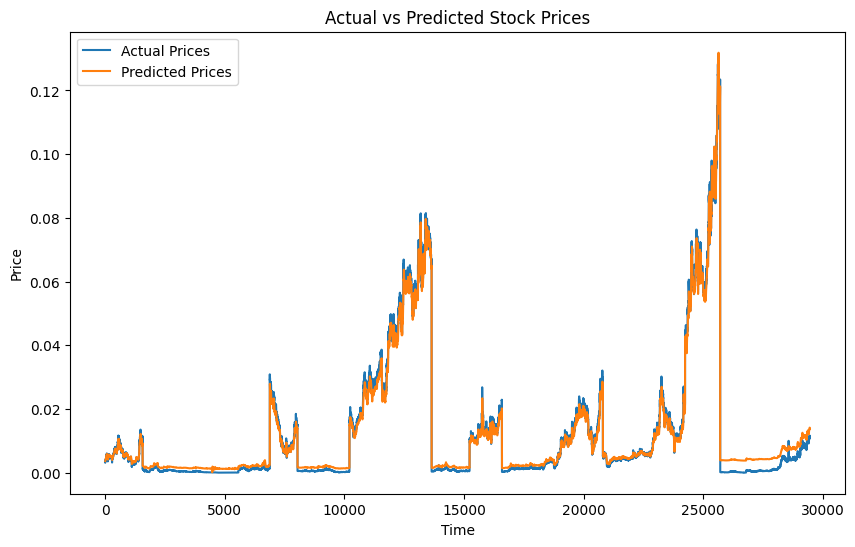

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Embedding, Flatten, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

data = pd.read_csv('stocks_df.csv')

data['Date'] = pd.to_datetime(data['Date'])

label_encoder = LabelEncoder()
data['Stock_Encoded'] = label_encoder.fit_transform(data['Stock'])

features = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Stock_Encoded']].values

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

sequence_length = 30
X, y = [], []

for stock_id in data['Stock_Encoded'].unique():
    stock_data = scaled_features[data['Stock_Encoded'] == stock_id]
    for i in range(len(stock_data) - sequence_length):
        X.append(stock_data[i:i+sequence_length])
        y.append(stock_data[i+sequence_length, 3])

X = np.array(X)
y = np.array(y)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

input_sequence = Input(shape=(sequence_length, 5))
input_stock = Input(shape=(1,))


lstm_layer_1 = LSTM(units=50, return_sequences=True)(input_sequence)
dropout_layer_1 = Dropout(0.2)(lstm_layer_1)
lstm_layer_2 = LSTM(units=50, return_sequences=False)(dropout_layer_1)
dropout_layer_2 = Dropout(0.2)(lstm_layer_2)


embedding_layer = Embedding(input_dim=len(data['Stock_Encoded'].unique()), output_dim=10)(input_stock)
flatten_layer = Flatten()(embedding_layer)

concat_layer = Concatenate()([dropout_layer_2, flatten_layer])


dense_layer_1 = Dense(units=25, activation='relu')(concat_layer)
output_layer = Dense(units=1)(dense_layer_1)


model = tf.keras.Model(inputs=[input_sequence, input_stock], outputs=output_layer)


model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

X_train_stock = X_train[:, -1, -1]
X_val_stock = X_val[:, -1, -1]


X_train = X_train[:, :, :-1]
X_val = X_val[:, :, :-1]

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    [X_train, X_train_stock], y_train,
    validation_data=([X_val, X_val_stock], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

loss, mae = model.evaluate([X_val, X_val_stock], y_val)
print(f"Validation Loss: {loss}, Validation MAE: {mae}")

y_pred = model.predict([X_val, X_val_stock])

plt.figure(figsize=(10, 6))
plt.plot(y_val, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.legend()
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()